# Google Colab: QLoRA-дообучение Qwen3-4B на ECQL + полный отчёт

Ноутбук рассчитан на Tesla T4 16 ГБ. Он обучает только ответ ECQL:
system/user prompt исключён из loss с помощью `labels=-100`.

Отчётная часть повторяет полный набор результатов из `notebooks/report_local`:
кривая обучения, сводка обучения, метрики синтаксиса/логики ECQL, доля
SQL-галлюцинаций, сравнительная таблица, LLM-as-a-judge (YandexGPT Pro,
опционально), анализ ошибок. Все артефакты сохраняются в `/content/results`.

In [1]:
# 1. Зависимости (версии зафиксированы для совместимости с локальным пайплайном)
%pip uninstall -y transformers tokenizers huggingface-hub fsspec gcsfs
%pip install -q -U --no-cache-dir \
    "transformers>=4.52.4,<5" \
    "huggingface-hub>=0.30,<1.0" \
    "tokenizers>=0.21,<0.22" \
    "fsspec[http]==2024.12.0" \
    "datasets==3.3.0" \
    "trl==0.16.0" \
    "peft==0.14.0" \
    "accelerate==1.3.0" \
    bitsandbytes

print("Зависимости установлены. Выполните Runtime → Restart session, затем продолжайте с ячейки ниже.")

Found existing installation: transformers 5.15.0
Uninstalling transformers-5.15.0:
  Successfully uninstalled transformers-5.15.0
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
Found existing installation: huggingface_hub 1.27.0
Uninstalling huggingface_hub-1.27.0:
  Successfully uninstalled huggingface_hub-1.27.0
Found existing installation: fsspec 2025.3.0
Uninstalling fsspec-2025.3.0:
  Successfully uninstalled fsspec-2025.3.0
Found existing installation: gcsfs 2025.3.0
Uninstalling gcsfs-2025.3.0:
  Successfully uninstalled gcsfs-2025.3.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 10.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 187.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 194.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 137.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/

## После перезапуска runtime

Запустите следующие ячейки по порядку. Загрузите `ecql_train.jsonl` и
`ecql_test.jsonl` в `/content/data/`.

In [2]:
# 2. Окружение, конфигурация, пути
import json
import time
from pathlib import Path

import torch

print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())
if not torch.cuda.is_available():
    raise RuntimeError("В Colab включите Runtime → Change runtime type → T4 GPU.")
GPU_NAME = torch.cuda.get_device_name(0)
print("device:", GPU_NAME)

TCFG = {
    "base_model": "Qwen/Qwen3-4B",
    "max_seq_length": 512,
    "num_train_epochs": 3,
    "per_device_train_batch_size": 2,
    "gradient_accumulation_steps": 4,
    "learning_rate": 2e-4,
    "lr_scheduler_type": "cosine",
    "warmup_ratio": 0.05,
    "lora_r": 4,
    "lora_alpha": 16,
    "lora_dropout": 0.05,
    "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    "optim": "paged_adamw_8bit",
}
MAX_NEW_TOKENS = 128

DATA_DIR = Path("/content/data")
RESULTS_DIR = Path("/content/results")
ADAPTER_DIR = Path("/content/ecql_adapter")
for d in (DATA_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

NOTEBOOK_START = time.time()
print(f"Результаты будут сохранены в: {RESULTS_DIR}")

torch: 2.11.0+cu128 | cuda: True
device: Tesla T4
Результаты будут сохранены в: /content/results


In [3]:
# 3. Загрузка датасета
from google.colab import files

print("Загрузите ecql_train.jsonl и ecql_test.jsonl")
uploaded = files.upload()
for filename in uploaded:
    target = DATA_DIR / filename
    Path(filename).replace(target)


def load_rows(path):
    if not path.exists():
        raise FileNotFoundError(f"Не найден файл: {path}")
    with path.open(encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]


train_rows = load_rows(DATA_DIR / "ecql_train.jsonl")
test_rows = load_rows(DATA_DIR / "ecql_test.jsonl")

Загрузите ecql_train.jsonl и ecql_test.jsonl


Saving ecql_test.jsonl to ecql_test.jsonl
Saving ecql_train.jsonl to ecql_train.jsonl


## Обзор датасета

Пары «русский запрос -> ECQL», сгенерированные моделью-учителем YandexGPT Pro.
Разбиение 80/20 сделано локально (`scripts/generate_dataset.py`).

In [4]:
entities_seen = sorted({r["output"].split("[")[1].split("]")[0] for r in train_rows + test_rows if "[" in r["output"]})
formats_seen = sorted({r["output"].rsplit("AS ", 1)[-1] for r in train_rows + test_rows if " AS " in r["output"]})
print(f"Всего пар: {len(train_rows) + len(test_rows)} | Train: {len(train_rows)} | Test: {len(test_rows)}")
print(f"Сущности: {entities_seen}")
print(f"Форматы вывода: {formats_seen}")

print("\nПримеры из датасета:")
for r in train_rows[:5]:
    print(f"  RU : {r['input']}")
    print(f"  ECQ: {r['output']}\n")

Всего пар: 201 | Train: 160 | Test: 41
Сущности: ['DEALS', 'EMPLOYEES', 'INVENTORY', 'PROJECTS']
Форматы вывода: ['JSON', 'LIST', 'TABLE']

Примеры из датасета:
  RU : Выведи список сотрудников, чья зарплата больше 150 тысяч и опыт работы больше 5 лет
  ECQ: FETCH [EMPLOYEES] WHERE @salary ABOVE 150000 && @experience ABOVE 5

  RU : Какие проекты имеют статус 'В процессе' и приоритет 'Высокий'?
  ECQ: FETCH [PROJECTS] WHERE @status IS 'In progress' && @priority IS 'High'

  RU : Кто из сотрудников имеет стаж работы больше 10 лет и зарплату больше 300 000?
  ECQ: FETCH [EMPLOYEES] WHERE @experience ABOVE 10 && @salary ABOVE 300000

  RU : Покажи все проекты, у которых статус не 'Completed' и бюджет ниже 1 000 000
  ECQ: FETCH [PROJECTS] WHERE (@status NOT 'Completed') && (@budget BELOW 1000000)

  RU : Найти все товары на складе в категории 'Electronics'
  ECQ: FETCH [INVENTORY] WHERE @category IS 'Electronics'



In [5]:
# 4. Базовая модель в 4-bit (NF4, double quant)
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained(TCFG["base_model"])
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    TCFG["base_model"],
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map="auto",
)
model.config.pad_token_id = tokenizer.pad_token_id
model.config.use_cache = False
print(f"Модель загружена за {time.time() - t0:.1f} c")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

model-00001-of-00003.safetensors:   0%|          | 0.00/3.96G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/99.6M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Модель загружена за 215.9 c


In [6]:
# 5. SFT-датасет: маскирование промпта через labels=-100
from datasets import Dataset

SYSTEM_PROMPT = (
    "Ты переводишь запросы с русского языка на корпоративный язык запросов ECQL. "
    "Отвечай только самим ECQL-запросом, без пояснений."
)


def build_sft_dataset(rows, tokenizer):
    def tokenize_row(row):
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": f"{row['instruction']}\n\n{row['input']}"},
        ]
        prefix = tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
        )
        answer = tokenizer.encode(
            f"\n{row['output']}",
            add_special_tokens=False,
        ) + [tokenizer.eos_token_id]

        input_ids = (prefix + answer)[: TCFG["max_seq_length"]]
        labels = ([-100] * len(prefix) + answer)[: TCFG["max_seq_length"]]

        return {
            "input_ids": input_ids,
            "attention_mask": [1] * len(input_ids),
            "labels": labels,
        }

    return Dataset.from_list([tokenize_row(row) for row in rows])


train_dataset = build_sft_dataset(train_rows, tokenizer)
lengths = [len(row["input_ids"]) for row in train_dataset]
avg_len = sum(lengths) / len(lengths)
print(f"Примеров: {len(train_dataset)} | tokens min/avg/max: {min(lengths)}/{avg_len:.1f}/{max(lengths)}")
print(train_dataset.column_names)

Примеров: 160 | tokens min/avg/max: 91/109.1/148
['input_ids', 'attention_mask', 'labels']


In [7]:
# 6. Коллатор: паддинг до кратности 8, labels дополняются -100
class ECQLDataCollator:
    def __init__(self, tokenizer, pad_to_multiple_of=8):
        self.tokenizer = tokenizer
        self.pad_to_multiple_of = pad_to_multiple_of

    def __call__(self, features):
        features = [dict(feature) for feature in features]
        labels = [feature.pop("labels") for feature in features]
        batch = self.tokenizer.pad(
            features,
            padding=True,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt",
        )
        max_length = batch["input_ids"].shape[1]
        batch["labels"] = torch.tensor(
            [label + [-100] * (max_length - len(label)) for label in labels],
            dtype=torch.long,
        )
        return batch


data_collator = ECQLDataCollator(tokenizer)
test_batch = data_collator([train_dataset[0], train_dataset[1]])
{key: tuple(value.shape) for key, value in test_batch.items()}

You're using a Qwen2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


{'input_ids': (2, 120), 'attention_mask': (2, 120), 'labels': (2, 120)}

In [8]:
# 7. LoRA + SFTTrainer (+ логирование loss как LossLoggingCallback в src/ecql/train.py)
from peft import LoraConfig
from transformers import TrainerCallback
from trl import SFTConfig, SFTTrainer


class ColabLossLogger(TrainerCallback):
    """Собирает (step, loss, elapsed_sec, lr) — тот же формат, что results/loss_log.csv."""

    def __init__(self, start_time: float):
        self.start_time = start_time
        self.rows: list[tuple[int, float, float, float]] = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            self.rows.append(
                (
                    int(state.global_step),
                    round(float(logs["loss"]), 5),
                    round(time.time() - self.start_time, 1),
                    float(logs.get("learning_rate", 0.0)),
                )
            )


loss_logger = ColabLossLogger(start_time=NOTEBOOK_START)

lora_config = LoraConfig(
    r=TCFG["lora_r"],
    lora_alpha=TCFG["lora_alpha"],
    lora_dropout=TCFG["lora_dropout"],
    target_modules=TCFG["target_modules"],
    task_type="CAUSAL_LM",
    bias="none",
)

sft_config = SFTConfig(
    output_dir="/content/checkpoints",
    max_seq_length=TCFG["max_seq_length"],
    per_device_train_batch_size=TCFG["per_device_train_batch_size"],
    gradient_accumulation_steps=TCFG["gradient_accumulation_steps"],
    num_train_epochs=TCFG["num_train_epochs"],
    learning_rate=TCFG["learning_rate"],
    lr_scheduler_type=TCFG["lr_scheduler_type"],
    warmup_ratio=TCFG["warmup_ratio"],
    logging_strategy="steps",
    logging_steps=1,
    save_strategy="epoch",
    optim=TCFG["optim"],
    fp16=True,
    bf16=False,
    seed=42,
    report_to=[],
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_dataset,
    processing_class=tokenizer,
    peft_config=lora_config,
    data_collator=data_collator,
    callbacks=[loss_logger],
)
print("Trainer готов, запускаем обучение.")

Truncating train dataset:   0%|          | 0/160 [00:00<?, ? examples/s]

Trainer готов, запускаем обучение.


## Обучение

QLoRA 4-bit: LoRA r=4 alpha=16 на всех проекциях внимания и MLP, эффективный
batch=8 (2 x grad_accum=4), lr=2e-4 (cosine), 3 эпохи.

In [9]:
TRAIN_START = time.time()
result = trainer.train()
train_elapsed = time.time() - TRAIN_START
print(f"Обучение заняло: {train_elapsed:.1f} c = {train_elapsed / 60:.1f} мин")
print(f"Шагов: {result.global_step} | train_loss: {result.training_loss:.4f}")

ADAPTER_DIR.mkdir(parents=True, exist_ok=True)
trainer.save_model(str(ADAPTER_DIR))
tokenizer.save_pretrained(str(ADAPTER_DIR))
print(f"Адаптер сохранён: {ADAPTER_DIR}")

Step,Training Loss
1,5.961600
2,6.274800
3,6.009700
4,5.269500
5,3.075600
6,2.473000
7,1.752800
8,1.048000
9,0.886500
10,0.678600


Обучение заняло: 160.6 c = 2.7 мин
Шагов: 60 | train_loss: 0.6256
Адаптер сохранён: /content/ecql_adapter


In [10]:
# 8. Сводка обучения (формат идентичен results/train_local.json)
train_summary = {
    "elapsed_sec": round(train_elapsed, 1),
    "global_step": result.global_step,
    "training_loss": float(result.training_loss),
    "train_samples": len(train_rows),
    "base_model": TCFG["base_model"],
    "lora_r": TCFG["lora_r"],
    "lora_alpha": TCFG["lora_alpha"],
    "device": "cuda",
    "gpu": GPU_NAME,
    "quantization": "4bit_nf4",
    "adapter_dir": str(ADAPTER_DIR),
}
train_json = RESULTS_DIR / "train_colab.json"
train_json.write_text(json.dumps(train_summary, ensure_ascii=False, indent=2), encoding="utf-8")
for k, v in train_summary.items():
    print(f"  {k:<22}: {v}")

  elapsed_sec           : 160.6
  global_step           : 60
  training_loss         : 0.6256281052172805
  train_samples         : 160
  base_model            : Qwen/Qwen3-4B
  lora_r                : 4
  lora_alpha            : 16
  device                : cuda
  gpu                   : Tesla T4
  quantization          : 4bit_nf4
  adapter_dir           : /content/ecql_adapter


## Кривая обучения (Loss Curve)

Лог loss пишется тем же форматом CSV, что и локальный прогон
(`results/loss_log.csv`: step,loss,elapsed_sec,lr).

Лог loss сохранён: /content/results/loss_log.csv
График сохранён: /content/results/loss_curve.png
Шагов: 60 | старт loss=5.962 | финиш loss=0.014


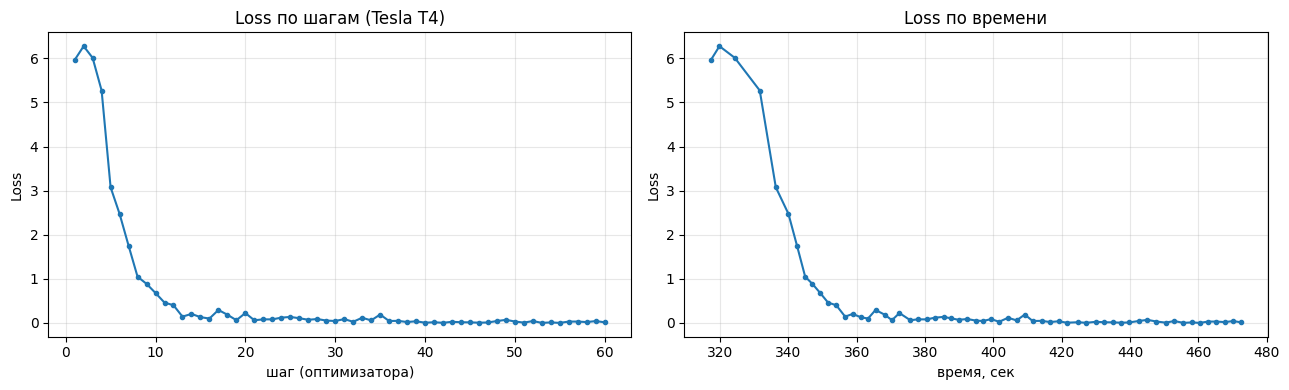

In [11]:
import matplotlib.pyplot as plt

loss_csv = RESULTS_DIR / "loss_log.csv"
with loss_csv.open("w", encoding="utf-8", newline="") as fh:
    fh.write("step,loss,elapsed_sec,lr\n")
    for s, loss_val, sec, lr in loss_logger.rows:
        fh.write(f"{s},{loss_val},{sec},{lr}\n")
print(f"Лог loss сохранён: {loss_csv}")

steps = [r[0] for r in loss_logger.rows]
losses = [r[1] for r in loss_logger.rows]
secs = [r[2] for r in loss_logger.rows]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(steps, losses, marker="o", ms=3)
ax1.set_xlabel("шаг (оптимизатора)")
ax1.set_ylabel("Loss")
ax1.set_title(f"Loss по шагам ({GPU_NAME})")
ax1.grid(alpha=0.3)
ax2.plot(secs, losses, marker="o", ms=3)
ax2.set_xlabel("время, сек")
ax2.set_ylabel("Loss")
ax2.set_title("Loss по времени")
ax2.grid(alpha=0.3)
fig.tight_layout()

loss_png = RESULTS_DIR / "loss_curve.png"
fig.savefig(loss_png, dpi=130)
print(f"График сохранён: {loss_png}")
print(f"Шагов: {len(steps)} | старт loss={losses[0]:.3f} | финиш loss={losses[-1]:.3f}")
plt.show(fig)

## Генерация ответов на тестовой выборке

In [12]:
# Qwen checkpoint may contain sampling defaults, while we use greedy decoding.
# Remove them once before the evaluation loop.
model.generation_config.do_sample = False
model.generation_config.temperature = None
model.generation_config.top_p = None
model.generation_config.top_k = None

model.config.use_cache = True
model.eval()


def generate_ecql(model, tokenizer, instruction, user_input, max_new_tokens=128):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"{instruction}\n\n{user_input}"},
    ]

    prompt_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt_text,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(model.device)

    with torch.inference_mode():
        output = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    generated_ids = output[0, inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

## Спецификация ECQL (инлайн-копия src/ecql/ecql_spec.py)

Грамматика: `FETCH [ENTITY] (WHERE expr)? (AS FORMAT)?`,
условия `@FIELD OP VALUE`, связки `&&` / `||`, операторы IS/NOT/ABOVE/BELOW.

In [13]:
import re

ECQL_ENTITIES: dict[str, set[str]] = {
    "EMPLOYEES": {
        "name", "city", "department", "position", "salary", "age", "status",
        "experience",
    },
    "PROJECTS": {
        "name", "status", "budget", "deadline", "owner", "team_size", "priority",
    },
    "INVENTORY": {
        "name", "category", "quantity", "price", "location", "status",
    },
    "DEALS": {
        "client", "amount", "currency", "date", "status", "manager",
    },
}
ECQL_OPERATORS = {"IS", "NOT", "ABOVE", "BELOW"}
ECQL_FORMATS = {"JSON", "TABLE", "LIST"}
ECQL_AND = "&&"
ECQL_OR = "||"

RE_QUERY = re.compile(
    r"^\s*FETCH\s+\[(?P<entity>[A-Z][A-Z_]*)\]"
    r"(?:\s+WHERE\s+(?P<where>.+?))?"
    r"(?:\s+AS\s+(?P<format>JSON|TABLE|LIST))?\s*$",
    re.DOTALL,
)
RE_COND = re.compile(
    r"^\s*@(?P<field>[a-z][a-z_]*)\s+"
    r"(?P<op>IS|NOT|ABOVE|BELOW)\s+"
    r"(?P<value>'(?:[^'\\]|\\.)*'|-?\d+(?:\.\d+)?)\s*$"
)


def split_conditions(expr):
    parts, ops = [], []
    depth = 0
    current = ""
    i = 0
    n = len(expr)
    while i < n:
        if expr[i] == "(":
            depth += 1
        elif expr[i] == ")":
            depth -= 1
        if depth == 0 and expr.startswith(ECQL_AND, i):
            parts.append(current)
            ops.append(ECQL_AND)
            current = ""
            i += 2
            continue
        if depth == 0 and expr.startswith(ECQL_OR, i):
            parts.append(current)
            ops.append(ECQL_OR)
            current = ""
            i += 2
            continue
        current += expr[i]
        i += 1
    parts.append(current)
    return parts, ops


def validate_condition(cond, entity, errors, collected):
    cond = cond.strip()
    if cond.startswith("(") and cond.endswith(")"):
        return validate_where(cond[1:-1], entity, errors, collected)
    m = RE_COND.match(cond)
    if not m:
        errors.append(f"Некорректное условие: {cond!r}")
        return False
    field, op, value = m.group("field"), m.group("op"), m.group("value")
    if op not in ECQL_OPERATORS:
        errors.append(f"Неизвестный оператор: {op}")
        return False
    if field not in ECQL_ENTITIES.get(entity, set()):
        errors.append(f"Поле @{field} не существует у сущности [{entity}]")
        return False
    if op in {"ABOVE", "BELOW"} and not re.match(r"^-?\d+(\.\d+)?$", value):
        errors.append(f"Оператор {op} требует числовое значение: {value!r}")
        return False
    collected.append({"field": field, "op": op, "value": value})
    return True


def validate_where(expr, entity, errors, collected):
    parts, ops = split_conditions(expr)
    if not parts:
        errors.append("Пустое WHERE-выражение")
        return False
    if len(ops) + 1 != len(parts):
        errors.append("Некорректное сочетание логических связок")
        return False
    ok = True
    for part in parts:
        ok = validate_condition(part, entity, errors, collected) and ok
    return ok


def parse_ecql(query):
    q = query.strip().strip("`")
    parsed = {"entity": "", "conditions": [], "operators": [], "output_format": None, "errors": [], "raw": q}
    m = RE_QUERY.match(q)
    if not m:
        parsed["errors"].append("Запрос должен начинаться с FETCH [СУЩНОСТЬ]")
        return parsed
    entity = m.group("entity")
    parsed["entity"] = entity
    if entity not in ECQL_ENTITIES:
        parsed["errors"].append(f"Неизвестная сущность [{entity}]")
    where = m.group("where")
    if where:
        validate_where(where, entity, parsed["errors"], parsed["conditions"])
        _, ops = split_conditions(where)
        parsed["operators"] = ops
    fmt = m.group("format")
    if fmt and fmt not in ECQL_FORMATS:
        parsed["errors"].append(f"Неизвестный формат вывода: {fmt}")
    parsed["output_format"] = fmt
    return parsed


def describe(query):
    p = parse_ecql(query)
    valid = not p["errors"]
    return {
        "entity": p["entity"] if valid else None,
        "fields": sorted({c["field"] for c in p["conditions"]}),
        "ops": sorted({c["op"] for c in p["conditions"]}),
        "logic": p["operators"],
        "format": p["output_format"],
    }


def is_sql_style(query):
    q = query.strip().upper()
    markers = (
        "SELECT ",
        " FROM ",
        " WHERE ",
        "JOIN",
        "GROUP BY",
        "ORDER BY",
        "CREATE TABLE",
        "INSERT INTO",
        "UPDATE ",
    )
    return any(m in q for m in markers) and not q.startswith("FETCH")


print("Парсер ECQL готов")
print("  эталон:", describe(test_rows[0]["output"]))
print("  SQL-пример:", is_sql_style("SELECT * FROM employees WHERE salary > 100"))

Парсер ECQL готов
  эталон: {'entity': 'INVENTORY', 'fields': ['quantity'], 'ops': ['BELOW'], 'logic': [], 'format': None}
  SQL-пример: True


## Оценка на тестовой выборке

Метрики те же, что в `src/ecql/eval.py`: синтаксическая корректность (парсер
ECQL), точное совпадение, совпадение сущности/полей/операторов/логики/формата,
доля SQL-галлюцинаций, среднее время инференса.

In [14]:
n_test = len(test_rows)
preds = []
t0 = time.time()

for i, row in enumerate(test_rows):
    start = time.time()
    prediction = generate_ecql(model, tokenizer, row["instruction"], row["input"], MAX_NEW_TOKENS)
    reference = row["output"]

    parsed = parse_ecql(prediction) if not is_sql_style(prediction) else None
    syntax_valid = parsed is not None and not parsed["errors"]
    pred_descr = describe(prediction) if syntax_valid else {}
    ref_descr = describe(reference)

    preds.append({
        "input": row["input"],
        "reference": reference,
        "prediction": prediction,
        "syntax_valid": syntax_valid,
        "sql_hallucination": is_sql_style(prediction),
        "exact_match": prediction.strip() == reference.strip(),
        "entity_match": pred_descr.get("entity") == ref_descr["entity"],
        "fields_match": pred_descr.get("fields") == ref_descr["fields"],
        "ops_match": pred_descr.get("ops") == ref_descr["ops"],
        "logic_match": pred_descr.get("logic") == ref_descr["logic"],
        "format_match": pred_descr.get("format") == ref_descr["format"],
        "inference_sec": round(time.time() - start, 2),
        "errors": [] if syntax_valid else (parsed["errors"] if parsed else ["SQL вместо ECQL"]),
    })
    print(f"  [{i + 1}/{n_test}] {row['input'][:60]}...")

inference_elapsed = time.time() - t0


def aggregate(preds_list, judge_scores=None):
    def mean(key):
        vals = [p[key] for p in preds_list]
        return round(sum(vals) / len(vals), 4) if vals else 0.0

    if judge_scores:
        judge_ok = [s for s in judge_scores if s["score"] >= 4]
        j_mean = round(sum(s["score"] for s in judge_scores) / len(judge_scores), 2)
        j_pass = round(len(judge_ok) / len(judge_scores), 4)
    else:
        j_mean, j_pass = 0.0, 0.0
    return {
        "syntax_accuracy": mean("syntax_valid"),
        "exact_match": mean("exact_match"),
        "entity_accuracy": mean("entity_match"),
        "fields_accuracy": mean("fields_match"),
        "ops_accuracy": mean("ops_match"),
        "logic_accuracy": mean("logic_match"),
        "format_accuracy": mean("format_match"),
        "sql_hallucination_rate": mean("sql_hallucination"),
        "judge_avg_score": j_mean,
        "judge_pass_rate": j_pass,
        "avg_inference_sec": round(sum(p["inference_sec"] for p in preds_list) / len(preds_list), 2),
    }


eval_result = {
    "metrics": aggregate(preds),
    "n": n_test,
    "judged": 0,
    "predictions": preds,
    "judge_scores": [],
}

print(f"\nИнференс: {inference_elapsed:.1f} c, {inference_elapsed / n_test:.2f} c/пример")
print("=" * 60)
print("Сводка метрик на тестовой выборке")
print("=" * 60)
for k, v in eval_result["metrics"].items():
    print(f"  {k:<24}: {v}")


def save_eval():
    eval_json = RESULTS_DIR / "eval_colab.json"
    eval_json.write_text(json.dumps(eval_result, ensure_ascii=False, indent=2), encoding="utf-8")


save_eval()
print(f"\nМетрики сохранены: {RESULTS_DIR / 'eval_colab.json'}")

  [1/41] Назови все товары на складе, количество которых меньше 10...
  [2/41] Какие товары находятся в категории 'Офисная техника' и стоят...
  [3/41] Какие клиенты заключили сделки на сумму выше 10 000 долларов...
  [4/41] Найди всех сотрудников в Москве...
  [5/41] Какие сотрудники работают в отделе маркетинга и имеют зарпла...
  [6/41] Какие товары находятся в статусе 'На складе' и имеют количес...
  [7/41] Какие проекты имеют бюджет ниже 50 000 евро и приоритет 'Med...
  [8/41] Найти все проекты с бюджетом выше 100 000...
  [9/41] Покажи все проекты с приоритетом 'High', бюджетом больше 300...
  [10/41] Найти всех сотрудников, которые работают в Москве или Санкт-...
  [11/41] Найти все товары на складе с количеством меньше 10...
  [12/41] Найди все товары на складе в Москве...
  [13/41] Покажи все товары на складе в категории 'Офисная техника', к...
  [14/41] Покажи все проекты, у которых бюджет больше 1 000 000 и прио...
  [15/41] Найти всех сотрудников, которые работают в отделе

## Сравнительная таблица: вход — эталон — ответ модели

5 примеров из тестовой выборки (по заданию).

In [15]:
def print_comparison(result_dict, n=5):
    header = f"{'#':<3}{'Вход (рус.)':<45}{'Эталон ECQL':<55}{'Ответ модели':<55}{'Синт.'}"
    print(header)
    print("-" * 210)
    for i, p in enumerate(result_dict["predictions"][:n], 1):
        print(
            f"{i:<3}{p['input'][:44]:<45}{p['reference'][:54]:<55}"
            f"{p['prediction'][:54]:<55}{'✓' if p['syntax_valid'] else '✗'}"
        )


print_comparison(eval_result)

#  Вход (рус.)                                  Эталон ECQL                                            Ответ модели                                           Синт.
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1  Назови все товары на складе, количество кото FETCH [INVENTORY] WHERE @quantity BELOW 10             FETCH [INVENTORY] WHERE @quantity BELOW 10             ✓
2  Какие товары находятся в категории 'Офисная  FETCH [INVENTORY] WHERE @category IS 'Office equipment FETCH [INVENTORY] WHERE @category IS 'Офисная техника' ✓
3  Какие клиенты заключили сделки на сумму выше FETCH [DEALS] WHERE @amount ABOVE 10000 && @currency I FETCH [DEALS] WHERE @amount ABOVE 10000                ✓
4  Найди всех сотрудников в Москве              FETCH [EMPLOYEES] WHERE @city IS 'Moscow'              FETCH [EMPLOYEES] WHERE @city IS 'Moscow' 

## LLM-as-a-judge (YandexGPT Pro, опционально)

Тот же промпт судьи, что в `src/ecql/yandex_client.py`. Введите ключ и folder_id
Yandex Cloud (запросятся ниже); если оставить пустыми — шаг будет пропущен.

In [17]:
from collections import Counter
from getpass import getpass

import requests


class YandexJudgeClient:
    """Минимальная копия YandexGPTClient для оценки пар «эталон vs ответ»."""

    def __init__(self, api_key, folder_id, model="yandexgpt-5.1/latest"):
        self.api_key = api_key
        self.folder_id = folder_id
        self.model = model
        self.url = "https://llm.api.cloud.yandex.net/foundationModels/v1/completion"

    def complete(self, prompt, system=None):
        messages = []
        if system:
            messages.append({"role": "system", "text": system})
        messages.append({"role": "user", "text": prompt})
        payload = {
            "modelUri": f"gpt://{self.folder_id}/{self.model}",
            "completionOptions": {"stream": False, "temperature": 0.0, "maxTokens": "800"},
            "messages": messages,
        }
        headers = {"Content-Type": "application/json", "Authorization": f"Api-Key {self.api_key}"}
        resp = requests.post(self.url, headers=headers, json=payload, timeout=180)
        resp.raise_for_status()
        return resp.json()["result"]["alternatives"][0]["message"]["text"]


def extract_json_objects(text):
    text = re.sub(r"```(?:json)?", "", text).replace("```", "")
    objects = []
    decoder = json.JSONDecoder()
    idx = 0
    while idx < len(text):
        if text[idx] == "{":
            try:
                obj, end = decoder.raw_decode(text, idx)
                objects.append(obj)
                idx = end
                continue
            except json.JSONDecodeError:
                pass
        idx += 1
    return objects


JUDGE_PROMPT = (
    "Ты — строгий эксперт-судья по корпоративному языку запросов ECQL. "
    "Оцени ответ дообученной модели по трём критериям:\n"
    "1) синтаксис (верно ли расставлены FETCH, [], @, &&/||, AS);\n"
    "2) логическая точность (та ли сущность, поля и операторы IS/NOT/ABOVE/BELOW);\n"
    "3) отсутствие галлюцинаций (не подменил ли ответ SQL-подобным синтаксисом).\n\n"
    "Запрос на русском: {ru}\n"
    "Эталонный ECQL: {ref}\n"
    "Ответ модели: {pred}\n\n"
    "Ответь строго одним JSON-объектом без пояснений:\n"
    '{{"score": <целое от 0 до 5>, "verdict": "correct"|"partial"|"incorrect", '
    '"comment": "<краткое пояснение на русском>"}}'
)

YC_API_KEY = getpass("YC_API_KEY (Enter — пропустить судью): ").strip()
YC_FOLDER_ID = getpass("YC_FOLDER_ID (Enter — пропустить судью): ").strip()

if YC_API_KEY and YC_FOLDER_ID:
    judge_client = YandexJudgeClient(YC_API_KEY, YC_FOLDER_ID)
    print("Оценка LLM-as-a-judge (YandexGPT Pro)...")
    for row, p in zip(test_rows, preds, strict=True):
        try:
            text = judge_client.complete(
                JUDGE_PROMPT.format(ru=row["input"], ref=row["output"], pred=p["prediction"]),
                system="Ты возвращаешь только валидный JSON.",
            )
            objs = extract_json_objects(text)
            if objs:
                verdict = {
                    "score": int(objs[0].get("score", 0)),
                    "verdict": str(objs[0].get("verdict", "incorrect")),
                    "comment": str(objs[0].get("comment", "")),
                    "raw_judge": text[:500],
                    "input": row["input"],
                    "prediction": p["prediction"],
                }
            else:
                verdict = {"score": 0, "verdict": "error", "comment": "Судья не вернул JSON",
                           "raw_judge": text[:500], "input": row["input"], "prediction": p["prediction"]}
        except Exception as exc:
            verdict = {"score": 0, "verdict": "error", "comment": f"Ошибка API: {exc}",
                       "raw_judge": "", "input": row["input"], "prediction": p["prediction"]}
        eval_result["judge_scores"].append(verdict)
        j_n = len(eval_result["judge_scores"])
        print(f"  judge {j_n}/{n_test}: score={verdict['score']} verdict={verdict['verdict']}")

    eval_result["judged"] = len(eval_result["judge_scores"])
    eval_result["metrics"].update(aggregate(preds, eval_result["judge_scores"]))
    save_eval()

judge_scores = eval_result["judge_scores"]
if judge_scores:
    verdicts = Counter(s["verdict"] for s in judge_scores)
    print("Вердикты судьи:", dict(verdicts))
    print(f"Средний балл: {eval_result['metrics']['judge_avg_score']} / 5")
    print(f"Доля score>=4: {eval_result['metrics']['judge_pass_rate']}")
    print()
    print("Примеры вердиктов судьи:")
    for s in judge_scores[:5]:
        print(f"  score={s['score']} [{s['verdict']}] {s['comment'][:70]}")
else:
    print("Судья пропущен (нет ключей Yandex Cloud). Метрики без judge_avg_score/judge_pass_rate.")

YC_API_KEY (Enter — пропустить судью): ··········
YC_FOLDER_ID (Enter — пропустить судью): ··········
Оценка LLM-as-a-judge (YandexGPT Pro)...
  judge 1/41: score=5 verdict=correct
  judge 2/41: score=4 verdict=partial
  judge 3/41: score=3 verdict=partial
  judge 4/41: score=5 verdict=correct
  judge 5/41: score=4 verdict=partial
  judge 6/41: score=4 verdict=partial
  judge 7/41: score=5 verdict=correct
  judge 8/41: score=5 verdict=correct
  judge 9/41: score=5 verdict=correct
  judge 10/41: score=5 verdict=correct
  judge 11/41: score=5 verdict=correct
  judge 12/41: score=5 verdict=correct
  judge 13/41: score=3 verdict=partial
  judge 14/41: score=5 verdict=correct
  judge 15/41: score=5 verdict=correct
  judge 16/41: score=4 verdict=partial
  judge 17/41: score=5 verdict=correct
  judge 18/41: score=5 verdict=correct
  judge 19/41: score=5 verdict=correct
  judge 20/41: score=5 verdict=correct
  judge 21/41: score=5 verdict=correct
  judge 22/41: score=5 verdict=correct
  judge 

## Анализ ошибок

Примеры, где модель ошиблась (невалидный синтаксис / SQL-галлюцинация).

In [18]:
bad = [p for p in preds if not p["syntax_valid"]]
if bad:
    for p in bad[:3]:
        print(f"  Вход : {p['input']}")
        print(f"  Эталон: {p['reference']}")
        print(f"  Ответ : {p['prediction']}")
        for err in p["errors"]:
            print(f"  Причина: {err}")
        print()
else:
    print("Все ответы синтаксически валидны.")

  Вход : Покажи все товары на складе в категории 'Офисная техника', кроме принтеров
  Эталон: FETCH [INVENTORY] WHERE @category IS 'Office Equipment' && @name NOT 'Printer'
  Ответ : FETCH [INVENTORY] WHERE @category IS 'Office Equipment' && NOT @type IS 'Printer'
  Причина: Некорректное условие: "NOT @type IS 'Printer'"

  Вход : Какие сделки были заключены в Москве или Санкт-Петербурге?
  Эталон: FETCH [DEALS] WHERE @client IS 'Moscow' || @client IS 'Saint Petersburg'
  Ответ : FETCH [DEALS] WHERE @city IS 'Moscow' || @city IS 'Saint Petersburg'
  Причина: Поле @city не существует у сущности [DEALS]
  Причина: Поле @city не существует у сущности [DEALS]



## Выводы

- Модель выучила каркас языка: `FETCH [ENTITY] WHERE ... && ... AS ...`
  (см. `syntax_accuracy`, `entity_accuracy`).
- Сложнее всего даётся замена SQL-привычек: `>`, `<`, `AND` вместо `ABOVE/BELOW/&&`
  (см. `sql_hallucination_rate` и раздел «Анализ ошибок»).
- LLM-as-a-judge (YandexGPT Pro) подтверждает семантическую близость ответов
  эталону (`judge_avg_score`, `judge_pass_rate`).
- Для сравнения с CPU-прогоном см. `notebooks/report_local_run.ipynb`
  и `results/eval_local.json`.

In [19]:
# 9. Выгрузка артефактов: результаты + LoRA-адаптер
import shutil

print(f"Полное время ноутбука: {round(time.time() - NOTEBOOK_START, 1)} c")
print(f"Результаты сохранены: {RESULTS_DIR}")

artifacts_zip = shutil.make_archive("/content/ecql_results", "zip", RESULTS_DIR)
adapter_zip = shutil.make_archive("/content/ecql_adapter", "zip", ADAPTER_DIR)
print(f"Архивы: {artifacts_zip}, {adapter_zip}")

try:
    from google.colab import files as colab_files

    colab_files.download(artifacts_zip)
    colab_files.download(adapter_zip)
except Exception as exc:
    print(f"Автоматическая загрузка не удалась ({exc}); скачайте архивы вручную из панели файлов.")

Полное время ноутбука: 988.0 c
Результаты сохранены: /content/results
Архивы: /content/ecql_results.zip, /content/ecql_adapter.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>